<a href="https://colab.research.google.com/github/theanhhoang/theanhhoang.github.io/blob/master/Percolation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [0]:
import numpy as np # linear algebra

import os
import seaborn
import matplotlib.pyplot as plt

%matplotlib inline

### Paper: Effect of information availability on stability of traffic flow: Percolation theory approach 
#### Authors: Alireza Talebpour, Hani S. Mahmassani, Samer H. Hamdar
#### Background:
The article makes use of Percolation theory to investigate the platoon string stability as the function of communication range and the traffic condition. It also considers market penetration rates of regular, connected and automated vehicle when studying stability of mixed platoons.

(To reproduce the results in this paper, another paper "Influence of connected and autonomous vehicles on traffic flow stability and throughput" (2016, the same authors) is also reviewed in order to review the concept of mixed traffic flow)

## Figure 5a: the results of Eq. (23) for different values of connected k-component sizes.
Set k = [3,4,5], Ac(R) belongs to [0,1]

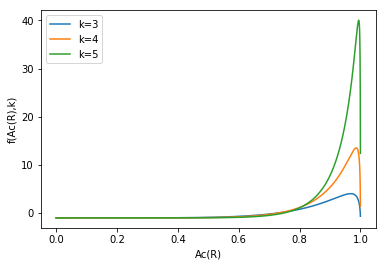

In [2]:
k = np.array([3,4,5])
A_c_R = np.linspace(0.0001,0.9999,10000)

def mu(A_c_R):
    return -np.log(1-A_c_R)

def critical_density(mu, k):
    a = 1- (mu+1)*np.exp(-mu)
    b = ((3*mu)**k)*np.exp(-mu)/np.math.factorial(k)
    return a*b-1

for i in k:
    plt.plot(A_c_R, critical_density(mu(A_c_R),i))
    
plt.legend(['k=3','k=4','k=5'])
plt.xlabel('Ac(R)')
plt.ylabel('f(Ac(R),k)')
plt.show()

## Figure 5b
Critical density for percolation based on transmission range

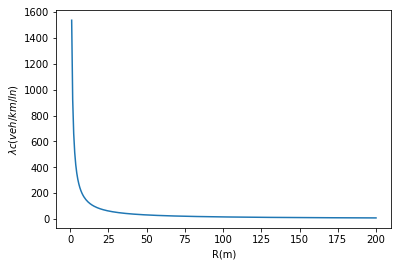

In [3]:
R= np.linspace(1, 200, 300)
lamda = -np.log(0.215)/(R/1000)

plt.xlabel('R(m)')
plt.ylabel(r'$\lambda c(veh/km/ln)$')
plt.plot(R, lamda)

## Figure7
Communication probability at different values of communication range and density (based on Percolation theory and Poisson distribution)

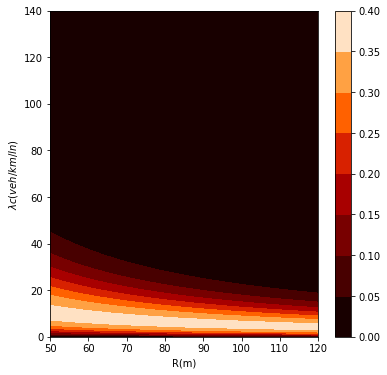

In [4]:
r = np.linspace(50,120, 200)
lamda = np.linspace(0,140, 200)

R, Lamda = np.meshgrid(r, lamda)
P = 2*(R/1000)*Lamda*np.exp(-2*(R/1000)*Lamda)


fig, ax = plt.subplots(figsize=(6,6))


# ax.set_aspect('equal')
cf = ax.contourf(R, Lamda, P, cmap='gist_heat')
fig.colorbar(cf, ax=ax)
plt.xlabel('R(m)')
plt.ylabel(r'$\lambda c(veh/km/ln)$')

plt.show()

## Section 5.2: Investigate linear string stability of a platoon of regular, connected, and autonomous vehicles at different market penetration rates.

### Moving onto figure 8 and 9, but first we need to declare three classes: 
####         regular_vehicle
####         connected_vehicle
####         autonomous_vehicle

In [0]:
# alpha = 0.08
# wc = 10000
# t_max = 4

class regular_vehicle:
    def __init__(self, v, alpha, wc, t_max):
        self.v = v
        self.alpha = alpha
        self.wc = wc
        self.t_max = t_max
    def fs(self):
        return 2/(np.square(self.t_max))
    def f_delta_v(self):
        return -2/self.t_max
    def z(self):
        return np.sqrt( 2*np.log(   self.wc*self.t_max/(2*np.sqrt(2*np.pi)*self.alpha*self.v)  )   )
    def fv(self):
        a1 = 2*self.alpha*self.z()/self.t_max
        a2 = 2*self.alpha*self.v/self.t_max
        a3 = 1/(np.sqrt(2)*self.v)
        a4 = np.log(  self.wc*self.t_max/(2*np.sqrt(2*np.pi)*self.alpha*self.v)  )
        return a1 + a2*(a3*np.power(a4, -1/2))
    def stability(self):
        return np.square(self.fv())/2 - self.f_delta_v()*self.fv()-self.fs()

In [0]:
# delta = 4
# T = 4.5
# s_0 = 2.0
# a = 3
# b = 4
v_0 = 31 #any value that larger than max(v)

class connected_vehicle:
    def __init__(self, v, delta, T, s_0, a, b):
        self.v = v
        self.delta = delta
        self.T = T
        self.s_0 = s_0
        self.a = a
        self.b = b
    def s_e(self):
        return (self.s_0+self.v*self.T)/np.sqrt(1-np.power(self.v/v_0, self.delta))

    def fs(self):
        return (2*self.a/self.s_e())*np.square((self.s_0+self.T*self.v)/self.s_e())

    def f_delta_v(self):
        return (-self.v/self.s_e())*np.sqrt(self.a/self.b)*(self.s_0+self.T*self.v)/self.s_e()

    def fv(self):
        a1 = (-self.a*self.delta/v_0)*np.power(self.v/v_0, self.delta-1)
        a2 = (2*self.a*self.T/self.s_e())*(self.s_0+self.T*self.v)/self.s_e()
        return a1-a2
    def stability(self):
        return np.square(self.fv())/2 - self.f_delta_v()*self.fv()-self.fs()

In [0]:
# kd = 1.2
# kv = 0.58
class autonomous_vehicle:
    def __init__(self, v,kd, kv, tau):
        self.v = v
        self.kd = kd
        self.kv = kv
        self.tau = tau

    def fs(self):
        return self.kd

    def f_delta_v(self):
        return self.kv

    def fv(self):
        return -(self.kd*self.tau)
    def stability(self):
        return np.square(self.fv())/2 - self.f_delta_v()*self.fv()-self.fs()

## Figure 8a
The stability results with the full communication assumption.

In [0]:
# find_rearest function: find the closest v_e that makes stability equals 0
def find_nearest(array, value, v_e):
    array = np.asarray(array)
    if ((array>0).all()):
        return 9
    if ((array<0).all()):
        return -0.1
    if ((array==0).all()):
        return -0.1
    idx = np.argmax(stab[i,j]<0)
    return v_e[idx]

#### Note: 
##### In paper "The Impact of Cooperative Adaptive Cruise Control on Traffic-Flow Characteristics" by Van Arem et al. (2006), the recommended parameters for acceleration model Autonomous vehicles are k = 1.0, ka = 1.0, kv = 0.58, and kd = 0.1 and tau=0.5(s). However, to reproduce the authors results, we need to modify the parameters, with kd=1.2, kv=0.58 and tau=1

In [0]:
v_e = np.linspace(0.0005,9, 50)



pA = np.linspace(0,1,51)
pC = np.linspace(0,1,51)


pA2, pC2, v_e_2 = np.meshgrid(pA, pC, v_e, indexing='ij')

#Declare rh, ch and ah
rh = regular_vehicle(v_e_2, 0.08, 10000, 4)
ch = connected_vehicle(v_e_2, 4, 4.5, 2.0, 1.4, 2)
ah = autonomous_vehicle(v_e_2, 1.2, 0.58, 1.)

stab = pA2*np.square(rh.fs()*ch.fs())*(np.square(ah.fv())/2-ah.f_delta_v()*ah.fv()-ah.fs()) + \
        pC2*np.square(rh.fs()*ah.fs())*(np.square(ch.fv())/2-ch.f_delta_v()*ch.fv()-ch.fs()) + \
        (1-pC2-pA2)*np.square(ah.fs()*ch.fs())*(np.square(rh.fv())/2-rh.f_delta_v()*rh.fv()-rh.fs())


In [0]:
#stab3: the value of v_e which make the system become instable
stab3 = np.zeros((stab.shape[0], stab.shape[1]))
for i in range(stab.shape[0]):
    for j in range(stab.shape[0]):

        if ((pA[i]+ pC[j])>1):
            stab3[i,j] = -0.1
        else:
            stab3[i,j] = find_nearest(stab[i,j],0, v_e)

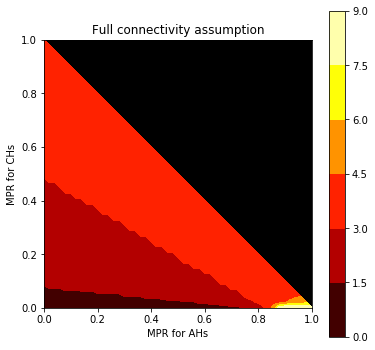

In [11]:
stab3 = np.ma.masked_where(stab3 < 0, stab3)
fig, ax = plt.subplots(figsize=(6,6))

fig.gca().patch.set_color('0.')
ax.set_aspect('equal')
cf = ax.contourf(pA, pC, stab3.T, [0. , 1.5, 3, 4.5, 6, 7.5 , 9], cmap='hot')
fig.colorbar(cf, ax=ax)
plt.xlabel('MPR for AHs')
plt.ylabel('MPR for CHs')
plt.title('Full connectivity assumption')
plt.show()

# Figure 8b to 8e
The stability results with different communication range.

In [0]:
#R: communication range
# lamda: the critical density to make percolation occur
# We choose lamda[2] to calculate P(the probability of a connected vehicle being inactive)

R= np.array([50,70,90,110,130])
lamda = -np.log(0.215)/(R/1000)

P = 2*(R/1000)*lamda[2]*np.exp(-2*(R/1000)*lamda[2])

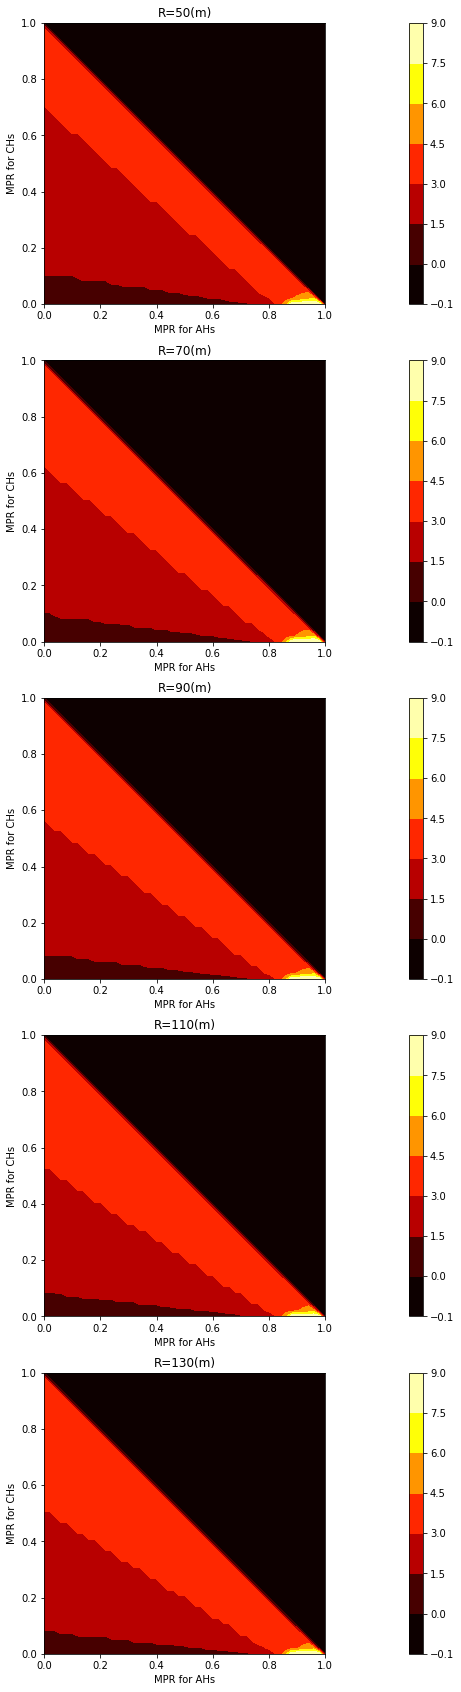

In [13]:
fig, ax = plt.subplots(5,1,figsize=(30,30))

for index, p in enumerate(P):
    stab = pA2*np.square(rh.fs()*ch.fs())*(np.square(ah.fv())/2-ah.f_delta_v()*ah.fv()-ah.fs()) + \
        (1-p)*pC2*np.square(rh.fs()*ah.fs())*(np.square(ch.fv())/2-ch.f_delta_v()*ch.fv()-ch.fs()) + \
        (1-pC2-pA2 + p*pC2)*np.square(ah.fs()*ch.fs())*(np.square(rh.fv())/2-rh.f_delta_v()*rh.fv()-rh.fs())
    stab3 = np.zeros((stab.shape[0], stab.shape[1]))
    for i in range(stab.shape[1]):
        for j in range(stab.shape[1]):
            if ((pA[i]+ pC[j])>=1):
                stab3[i,j] = -0.1
            else:
                stab3[i,j] = find_nearest(stab[i,j],0, v_e)
                

    ax[index].set_aspect('equal')
    cf = ax[index].contourf(pA, pC, stab3.T, [-0.1,0. , 1.5, 3, 4.5, 6, 7.5 , 9], cmap='hot')
    fig.colorbar(cf, ax=ax[index])
    ax[index].set(xlabel= 'MPR for AHs', ylabel = 'MPR for CHs', title='R={0}(m)'.format(R[index]))

plt.show()

## We increase in connected vehicles acceleration domain (a= 3.0m/s2 and b= −4.0m/s2), in order to magnify the effects of communication range on string stability of traffic flow and better indicates the importance of considering connectivity in studying the effects of connectivity and automation on string stability
### Figure 9a

The stability results with the full communication assumption.

In [0]:
v_e = np.linspace(0.0005,9, 50)



pA = np.linspace(0,1,51)
pC = np.linspace(0,1,51)


pA2, pC2, v_e_2 = np.meshgrid(pA, pC, v_e, indexing='ij')


rh = regular_vehicle(v_e_2, 0.08, 10000, 4)
ch = connected_vehicle(v_e_2, 4, 4.5, 2.0, 3, 4)
ah = autonomous_vehicle(v_e_2, 1.2, 0.58, 1.)

stab = pA2*np.square(rh.fs()*ch.fs())*(np.square(ah.fv())/2-ah.f_delta_v()*ah.fv()-ah.fs()) + \
        pC2*np.square(rh.fs()*ah.fs())*(np.square(ch.fv())/2-ch.f_delta_v()*ch.fv()-ch.fs()) + \
        (1-pC2-pA2)*np.square(ah.fs()*ch.fs())*(np.square(rh.fv())/2-rh.f_delta_v()*rh.fv()-rh.fs())


In [0]:
#stab3: the value of v_e which make the system become instable
stab3 = np.zeros((stab.shape[0], stab.shape[1]))
for i in range(stab.shape[0]):
    for j in range(stab.shape[0]):

        if ((pA[i]+ pC[j])>1):
            stab3[i,j] = -0.1
        else:
            stab3[i,j] = find_nearest(stab[i,j],0, v_e)

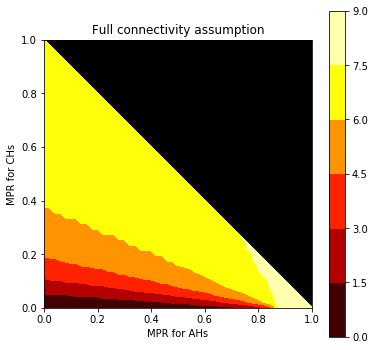

In [16]:
stab3 = np.ma.masked_where(stab3 < 0, stab3)
fig, ax = plt.subplots(figsize=(6,6))

fig.gca().patch.set_color('0.')
ax.set_aspect('equal')
cf = ax.contourf(pA, pC, stab3.T, [0. , 1.5, 3, 4.5, 6, 7.5 , 9], cmap='hot')
fig.colorbar(cf, ax=ax)
plt.xlabel('MPR for AHs')
plt.ylabel('MPR for CHs')
plt.title('Full connectivity assumption')
plt.show()

# Figure 9b to 9e
The stability results with different communication range.

In [0]:
#R: communication range
# lamda: the critical density to make percolation occur
# We choose lamda[2] to calculate P(the probability of a connected vehicle being inactive)

R= np.array([50,70,90,110,130])
lamda = -np.log(0.215)/(R/1000)

P = 2*(R/1000)*lamda[2]*np.exp(-2*(R/1000)*lamda[2])

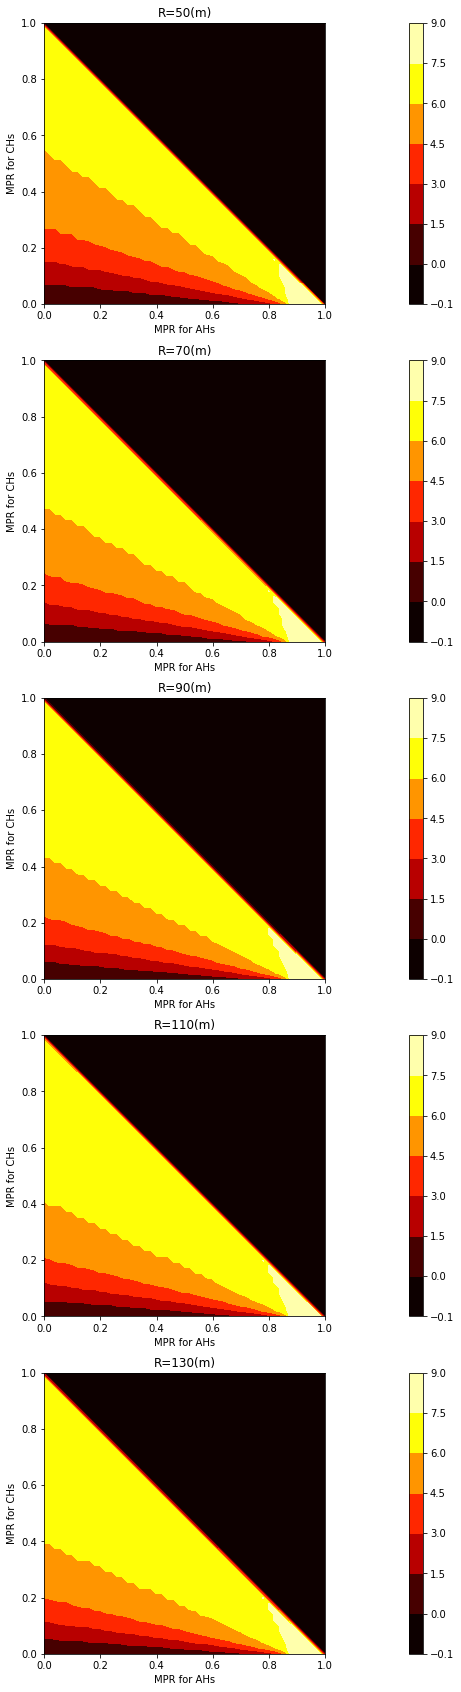

In [18]:
fig, ax = plt.subplots(5,1,figsize=(30,30))

for index, p in enumerate(P):
    stab = pA2*np.square(rh.fs()*ch.fs())*(np.square(ah.fv())/2-ah.f_delta_v()*ah.fv()-ah.fs()) + \
        (1-p)*pC2*np.square(rh.fs()*ah.fs())*(np.square(ch.fv())/2-ch.f_delta_v()*ch.fv()-ch.fs()) + \
        (1-pC2-pA2 + p*pC2)*np.square(ah.fs()*ch.fs())*(np.square(rh.fv())/2-rh.f_delta_v()*rh.fv()-rh.fs())
    stab3 = np.zeros((stab.shape[0], stab.shape[1]))
    for i in range(stab.shape[1]):
        for j in range(stab.shape[1]):
            if ((pA[i]+ pC[j])>=1):
                stab3[i,j] = -0.1
            else:
                stab3[i,j] = find_nearest(stab[i,j],0, v_e)
                

    ax[index].set_aspect('equal')
    cf = ax[index].contourf(pA, pC, stab3.T, [-0.1,0. , 1.5, 3, 4.5, 6, 7.5 , 9], cmap='hot')
    fig.colorbar(cf, ax=ax[index])
    ax[index].set(xlabel= 'MPR for AHs', ylabel = 'MPR for CHs', title='R={0}(m)'.format(R[index]))

plt.show()